<a href="https://colab.research.google.com/drive/1eQOkYB4XMQdSeHV_pKvt9kSUW8vQo6LQ">Abre este Jupyter en Google Colab</a>

# Regresión Logística: Detección de SPAM

En este ejercicio se muestran los fundamentos de la Regresión Logística planteando uno de los primeros problemas que fueron solucionados mediante el uso de técnicas de Machine Learning: la detección de SPAM.

## Enunciado del ejercicio

Se propone la construcción de un sistema de aprendizaje automático capaz de predecir si un correo determinado se corresponde con un correo de SPAM o no, para ello, se utilizará el siguiente conjunto de datos:

##### [2007 TREC Public Spam Corpus](https://plg.uwaterloo.ca/cgi-bin/cgiwrap/gvcormac/foo07)
The corpus trec07p contains 75,419 messages:

    25220 ham
    50199 spam

These messages constitute all the messages delivered to a particular
server between these dates:

    Sun, 8 Apr 2007 13:07:21 -0400
    Fri, 6 Jul 2007 07:04:53 -0400

### 0. Imports

In [ ]:
# Instalación de librerías externas
!pip install scikit-learn
!pip install nltk
!pip install pandas

### 1. Funciones complementarias

El conjunto de datos utilizado es `processed_data.csv`, que contiene correos ya procesados con las siguientes columnas:
- **label**: etiqueta del correo (1 = SPAM, 0 = ham)
- **subject**: asunto del correo
- **email_to**: destinatario
- **email_from**: remitente
- **message**: cuerpo del correo

In [1]:
import pandas as pd

# Cargamos el conjunto de datos preprocesado
df = pd.read_csv('processed_data.csv')
df.head()

,label,subject,email_to,email_from,message
0,1,"Generic Cialis, branded quality@",the00@speedy.uwaterloo.ca,"""Tomas Jacobs"" <RickyAmes@aol.com>",Content-Type: text/html;\nContent-Transfer-Enc...
1,0,Typo in /debian/README,debian-mirrors@lists.debian.org,Yan Morin <yan.morin@savoirfairelinux.com>,"Hi, i've just updated from the gulus and I che..."
2,1,authentic viagra,<the00@plg.uwaterloo.ca>,"""Sheila Crenshaw"" <7stocknews@tractionmarketin...","Content-Type: text/plain;\n\tcharset=""iso-8859..."
3,1,Nice talking with ya,opt4@speedy.uwaterloo.ca,"""Stormy Dempsey"" <vqucsmdfgvsg@ruraltek.com>","Hey Billy, \n\nit was really fun going out the..."
4,1,or trembling; stomach cramps; trouble in sleep...,ktwarwic@speedy.uwaterloo.ca,"""Christi T. Jernigan"" <dcube@totalink.net>",Content-Type: multipart/alternative;\n ...


In [2]:
print('Número de correos:', len(df))
print('Distribución de clases:')
print(df['label'].value_counts().rename({1: 'SPAM', 0: 'ham'}))

Número de correos: 75419
Distribución de clases:
label
SPAM    50199
ham     25220
Name: count, dtype: int64


In [3]:
# Ejemplo de un correo SPAM
df[df['label'] == 1].iloc[0][['subject', 'message']]

subject                    Generic Cialis, branded quality@ 
message    Content-Type: text/html;\nContent-Transfer-Enc...
Name: 0, dtype: object

Para preparar los datos para el algoritmo de Machine Learning, se combinan el asunto (`subject`) y el cuerpo (`message`) del correo en una única cadena de texto. Las etiquetas ya están codificadas numéricamente (1 = SPAM, 0 = ham), por lo que no requieren transformación adicional.

In [4]:
def prepare_texts(dataframe):
    """Combina subject y message en una sola cadena de texto por correo."""
    texts = (dataframe['subject'].fillna('') + ' ' + dataframe['message'].fillna('')).tolist()
    labels = dataframe['label'].tolist()
    return texts, labels

##### Vista de un correo individual

In [5]:
# Mostramos el texto completo del primer correo
print('Asunto:', df.iloc[0]['subject'])
print('De:    ', df.iloc[0]['email_from'])
print('Para:  ', df.iloc[0]['email_to'])
print('---')
print(df.iloc[0]['message'])

Asunto: Generic Cialis, branded quality@ 
De:     "Tomas Jacobs" <RickyAmes@aol.com>
Para:   the00@speedy.uwaterloo.ca
---
Content-Type: text/html;
Content-Transfer-Encoding: 7Bit Do you feel the pressure to perform and not rising to the occasion?? Try V ia gr a ..... your anxiety will be a thing of the past and you will be back to your old self.


##### Etiqueta del correo

In [6]:
label = df.iloc[0]['label']
print('Etiqueta:', 'SPAM' if label == 1 else 'ham')

Etiqueta: SPAM


##### Carga del conjunto completo

La función `prepare_texts` carga todos los correos combinando asunto y cuerpo, junto con sus etiquetas.

In [7]:
X, y = prepare_texts(df)
print(f'Total de correos: {len(X)}')
print(f'Ejemplo X[0]: {X[0][:100]}...')
print(f'Ejemplo y[0]: {y[0]}')

Total de correos: 75419
Ejemplo X[0]: Generic Cialis, branded quality@  Content-Type: text/html;
Content-Transfer-Encoding: 7Bit Do you fe...
Ejemplo y[0]: 1


In [8]:
# Mostramos los 10 primeros correos con sus etiquetas
for i in range(10):
    etiqueta = 'SPAM' if y[i] == 1 else 'ham'
    print(f'[{etiqueta}] {X[i][:80]}')

[SPAM] Generic Cialis, branded quality@  Content-Type: text/html;
Content-Transfer-Enco
[ham] Typo in /debian/README Hi, i've just updated from the gulus and I check on other
[SPAM] authentic viagra Content-Type: text/plain;
	charset="iso-8859-1"
Content-Transfe
[SPAM] Nice talking with ya Hey Billy, 

it was really fun going out the other night 
a
[SPAM] or trembling; stomach cramps; trouble in sleeping; weakness loose Content-Type: 
[SPAM] Which is duty Content-Type: multipart/alternative;
        boundary="----=_NextP
[SPAM] For Theorize Content-Type: text/plain;
	charset="Windows-1252"
Content-Transfer-
[SPAM] Theorize get inside for local esc0rts who do it all Content-Type: Multipart/Alte
[SPAM] Losing Weight Quickly Content-Type: text/plain;
    charset="iso-8859-1"
Content
[ham] [R] Confidence-Intervals.... help... Hi...

I have to use R to find out the 90% 


In [9]:
# Distribución de clases en el conjunto completo
import collections
counts = collections.Counter(y)
print(f'ham : {counts[0]}')
print(f'spam: {counts[1]}')

ham : 25220
spam: 50199


In [10]:
df.head()

,label,subject,email_to,email_from,message
0,1,"Generic Cialis, branded quality@",the00@speedy.uwaterloo.ca,"""Tomas Jacobs"" <RickyAmes@aol.com>",Content-Type: text/html;\nContent-Transfer-Enc...
1,0,Typo in /debian/README,debian-mirrors@lists.debian.org,Yan Morin <yan.morin@savoirfairelinux.com>,"Hi, i've just updated from the gulus and I che..."
2,1,authentic viagra,<the00@plg.uwaterloo.ca>,"""Sheila Crenshaw"" <7stocknews@tractionmarketin...","Content-Type: text/plain;\n\tcharset=""iso-8859..."
3,1,Nice talking with ya,opt4@speedy.uwaterloo.ca,"""Stormy Dempsey"" <vqucsmdfgvsg@ruraltek.com>","Hey Billy, \n\nit was really fun going out the..."
4,1,or trembling; stomach cramps; trouble in sleep...,ktwarwic@speedy.uwaterloo.ca,"""Christi T. Jernigan"" <dcube@totalink.net>",Content-Type: multipart/alternative;\n ...


### 2. Preprocesamiento de los datos del conjunto de datos

Con la función `prepare_texts` se obtienen los textos de cada correo (asunto + cuerpo) y sus etiquetas. Sin embargo, cada correo sigue siendo una cadena de texto, por lo que deben aplicarse transformaciones numéricas antes de introducirlos en el algoritmo.

In [11]:
# Cargamos el índice y las etiquetas en memoria desde el CSV
X, y = prepare_texts(df)

In [12]:
# Leemos el primer correo
print(X[0])

Generic Cialis, branded quality@  Content-Type: text/html;
Content-Transfer-Encoding: 7Bit Do you feel the pressure to perform and not rising to the occasion?? Try V ia gr a ..... your anxiety will be a thing of the past and you will be back to your old self.


In [13]:
# Parseamos el primer correo
label = y[0]
print('El correo es:', 'SPAM' if label == 1 else 'ham')
print(X[0][:200])

El correo es: SPAM
Generic Cialis, branded quality@  Content-Type: text/html;
Content-Transfer-Encoding: 7Bit Do you feel the pressure to perform and not rising to the occasion?? Try V ia gr a ..... your anxiety will be


El algoritmo de Regresión Logística no es capaz de ingerir texto como parte del conjunto de datos. Por lo tanto, deben aplicarse una serie de funciones adicionales que transformen el texto de los correos electrónicos parseados en una representación numérica.

##### Aplicación de CountVectorizer

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

# Preparación del email: combinamos subject y message
prep_email = [df.iloc[0]['subject'] + ' ' + df.iloc[0]['message']]

vectorizer = CountVectorizer()
vectorizer.fit(prep_email)

print('Email:', prep_email[0][:100], '...\n')
print('Características de entrada:', vectorizer.get_feature_names_out())

Email: Generic Cialis, branded quality@  Content-Type: text/html;
Content-Transfer-Encoding: 7Bit Do you fe ...

Características de entrada: ['7bit' 'and' 'anxiety' 'back' 'be' 'branded' 'cialis' 'content' 'do'
 'encoding' 'feel' 'generic' 'gr' 'html' 'ia' 'not' 'occasion' 'of' 'old'
 'past' 'perform' 'pressure' 'quality' 'rising' 'self' 'text' 'the'
 'thing' 'to' 'transfer' 'try' 'type' 'will' 'you' 'your']


In [15]:
X = vectorizer.transform(prep_email)
print("\nValues:\n", X.toarray())


Values:
 [[1 2 1 1 2 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 1 3 1 1 1 2 2 2]]


##### Aplicación de OneHotEncoding

In [16]:
from sklearn.preprocessing import OneHotEncoder

words = (df.iloc[0]['subject'] + ' ' + df.iloc[0]['message']).split()
prep_email = [[w] for w in words]

enc = OneHotEncoder(handle_unknown='ignore')
X_sample = enc.fit_transform(prep_email)

print('Features:\n', enc.get_feature_names_out())
print('\nValues:\n', X_sample.toarray())

Features:
 ['x0_.....' 'x0_7Bit' 'x0_Cialis,' 'x0_Content-Transfer-Encoding:'
 'x0_Content-Type:' 'x0_Do' 'x0_Generic' 'x0_Try' 'x0_V' 'x0_a' 'x0_and'
 'x0_anxiety' 'x0_back' 'x0_be' 'x0_branded' 'x0_feel' 'x0_gr' 'x0_ia'
 'x0_not' 'x0_occasion??' 'x0_of' 'x0_old' 'x0_past' 'x0_perform'
 'x0_pressure' 'x0_quality@' 'x0_rising' 'x0_self.' 'x0_text/html;'
 'x0_the' 'x0_thing' 'x0_to' 'x0_will' 'x0_you' 'x0_your']

Values:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


##### Funciones auxiliares para preprocesamiento del conjunto de datos

In [17]:
def create_prep_dataset(dataframe, n_elements=None):
    """Devuelve textos (subject + message) y etiquetas de los primeros n_elements correos."""
    subset = dataframe if n_elements is None else dataframe.iloc[:n_elements]
    X = (subset['subject'].fillna('') + ' ' + subset['message'].fillna('')).tolist()
    y = subset['label'].tolist()
    return X, y

### 3. Entrenamiento del algoritmo 

In [18]:
# Leemos únicamente un subconjunto de 100 correos electrónicos
X_train, y_train = create_prep_dataset(df, 100)
X_train

['Generic Cialis, branded quality@  Content-Type: text/html;\nContent-Transfer-Encoding: 7Bit Do you feel the pressure to perform and not rising to the occasion?? Try V ia gr a ..... your anxiety will be a thing of the past and you will be back to your old self.',
 'Typo in /debian/README Hi, i\'ve just updated from the gulus and I check on other mirrors.\nIt seems there is a little typo in /debian/README file\n\nExample:\nhttp://gulus.usherbrooke.ca/debian/README\nftp://ftp.fr.debian.org/debian/README\n\n"Testing, or lenny.  Access this release through dists/testing.  The\ncurrent tested development snapshot is named etch.  Packages which\nhave been tested in unstable and passed automated tests propogate to\nthis release."\n\netch should be replace by lenny like in the README.html\n\n\n\n-- \nYan Morin\nConsultant en logiciel libre\nyan.morin@savoirfairelinux.com\n514-994-1556\n\n\n-- \nTo UNSUBSCRIBE, email to debian-mirrors-REQUEST@lists.debian.org\nwith a subject of "unsubscribe". 

##### Aplicamos la vectorización a los datos

In [19]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train)

In [20]:
print(X_train.toarray())
print("\nFeatures:", len(vectorizer.get_feature_names_out()))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Features: 18329


In [21]:
import pandas as pd

pd.DataFrame(X_train.toarray(), columns=[vectorizer.get_feature_names_out()])

,00,000,0000,000301c634d3,000701c6c5da,000f01c7797d,000f01c77a12,000m,001301c77a13,001501c77a14,...,õ¹,õæ³ïï,õôõôèõéï,ö¹,öð,öôööµæ,öø³ðåµ,öþ,úàí,þîñòµ¼
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
y_train

[1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

###### Entrenamiento del algoritmo de regresión logística con el conjunto de datos preprocesado

In [23]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 4. Predicción

##### Lectura de un conjunto de correos nuevos

In [24]:
# Leemos 150 correos y nos quedamos únicamente con los 50 últimos
# Estos 50 correos no se han utilizado para entrenar el algoritmo
X, y = create_prep_dataset(df, 150)
X_test = X[100:]
y_test = y[100:]

##### Preprocesamiento de los correos con el vectorizador creado anteriormente

In [25]:
X_test = vectorizer.transform(X_test)

##### Predicción del tipo de correo

In [26]:
y_pred = clf.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1])

In [27]:
print("Predicción:\n", y_pred)
print("\nEtiquetas reales:\n", y_test)

Predicción:
 [1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]

Etiquetas reales:
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


##### Evaluación de los resultados

In [28]:
from sklearn.metrics import accuracy_score

print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))

Accuracy: 0.960


### 5. Aumentando el conjunto de datos

In [29]:
# Leemos todos los correos disponibles en el CSV
X, y = create_prep_dataset(df)

In [30]:
# Utilizamos 80% de los correos para entrenar el algoritmo y 20% para realizar pruebas
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test,  y_test  = X[split:], y[split:]

In [31]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train)

In [32]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

/home/sebas/Escritorio/Carlitos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
X_test = vectorizer.transform(X_test)

In [34]:
y_pred = clf.predict(X_test)

In [35]:
print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))

Accuracy: 0.992


### 6. Visualización del modelo

En la Regresión Logística el modelo aprende a asignar a cada correo una **probabilidad** de ser SPAM (eje Y), expresada mediante la función sigmoide. El gráfico ordena todos los correos del conjunto de prueba de menor a mayor probabilidad predicha:

- Cada **punto** representa un correo real: <span style='color:tomato'>rojo</span> = SPAM, <span style='color:steelblue'>azul</span> = ham.
- La **curva negra** es lo que predice el modelo (P(SPAM)).
- La **línea gris discontinua** marca el umbral de decisión en 0.5.

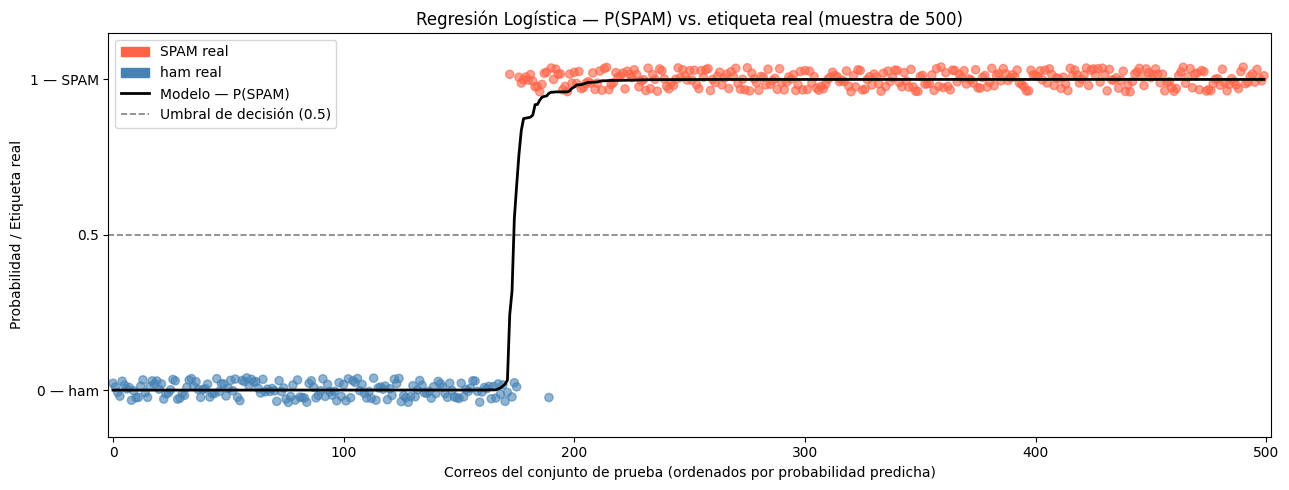

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

N_MUESTRA = None

probs_all = clf.predict_proba(X_test)[:, 1]
y_all     = np.array(y_test)

np.random.seed(42)
if N_MUESTRA is None or N_MUESTRA >= len(y_all):
    idx = np.arange(len(y_all))
    titulo_muestra = f'todos los datos ({len(y_all)})'
else:
    idx = np.random.choice(len(y_all), size=N_MUESTRA, replace=False)
    titulo_muestra = f'muestra de {N_MUESTRA}'

probs_sorted  = probs_all[idx][np.argsort(probs_all[idx])]
y_sorted      = y_all[idx][np.argsort(probs_all[idx])]

jitter  = np.random.uniform(-0.04, 0.04, size=len(y_sorted))
colores = ['tomato' if lbl == 1 else 'steelblue' for lbl in y_sorted]
punto_size = max(4, 40 - len(y_sorted) // 100)  # puntos más pequeños con más datos

fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(range(len(y_sorted)), y_sorted + jitter,
           c=colores, alpha=0.6, s=punto_size, zorder=2)
ax.plot(range(len(probs_sorted)), probs_sorted,
        color='black', linewidth=2, label='Modelo — P(SPAM)', zorder=3)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2,
           label='Umbral de decisión (0.5)', zorder=1)

spam_patch = mpatches.Patch(color='tomato',    label='SPAM real')
ham_patch  = mpatches.Patch(color='steelblue', label='ham real')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=[spam_patch, ham_patch] + handles, loc='upper left')

ax.set_xlabel('Correos del conjunto de prueba (ordenados por probabilidad predicha)')
ax.set_ylabel('Probabilidad / Etiqueta real')
ax.set_title(f'Regresión Logística — P(SPAM) vs. etiqueta real ({titulo_muestra})')
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['0 — ham', '0.5', '1 — SPAM'])
ax.set_xlim(-2, len(y_sorted) + 2)
ax.set_ylim(-0.15, 1.15)

plt.tight_layout()
plt.show()

### 7. Matriz de confusión

Muestra exactamente dónde se equivoca el modelo:
- **Verdaderos Positivos (VP)**: spam detectado correctamente
- **Verdaderos Negativos (VN)**: ham detectado correctamente
- **Falsos Positivos (FP)**: ham clasificado como spam *(correo legítimo en la papelera)*
- **Falsos Negativos (FN)**: spam clasificado como ham *(spam que se cuela en la bandeja de entrada)*

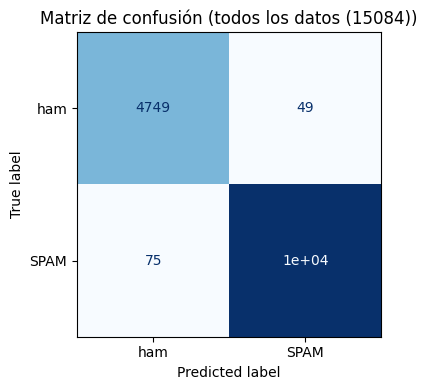

Verdaderos Negativos (ham correcto) : 4749
Falsos Positivos     (ham → SPAM)   : 49
Falsos Negativos     (SPAM → ham)   : 75
Verdaderos Positivos (SPAM correcto): 10211


In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Cambia este valor para ajustar la muestra ─────────────────────────────
N_MUESTRA_CM = None   # Usa None para usar todos los datos de prueba
# ──────────────────────────────────────────────────────────────────────────

probs_all = clf.predict_proba(X_test)[:, 1]
y_all     = np.array(y_test)

np.random.seed(42)
if N_MUESTRA_CM is None or N_MUESTRA_CM >= len(y_all):
    idx = np.arange(len(y_all))
    titulo_muestra = f'todos los datos ({len(y_all)})'
else:
    idx = np.random.choice(len(y_all), size=N_MUESTRA_CM, replace=False)
    titulo_muestra = f'muestra de {N_MUESTRA_CM}'

y_pred_cm = clf.predict(X_test[idx])
y_true_cm = y_all[idx]

cm = confusion_matrix(y_true_cm, y_pred_cm)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'SPAM'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(f'Matriz de confusión ({titulo_muestra})')
plt.tight_layout()
plt.show()

vn, fp, fn, vp = cm.ravel()
print(f'Verdaderos Negativos (ham correcto) : {vn}')
print(f'Falsos Positivos     (ham → SPAM)   : {fp}')
print(f'Falsos Negativos     (SPAM → ham)   : {fn}')
print(f'Verdaderos Positivos (SPAM correcto): {vp}')